No local CSV with pit-stop target column found. Attempting Kaggle download...
Path to dataset files: /kaggle/input/datasets/aadigupta1601/f1-strategy-dataset-pit-stop-prediction
Loaded dataset from: /kaggle/input/datasets/aadigupta1601/f1-strategy-dataset-pit-stop-prediction/f1_strategy_dataset_v4.csv
Dataset name: f1_strategy_dataset_v4
Raw dataset shape: (101371, 16)
Columns: ['Driver', 'LapNumber', 'Compound', 'Stint', 'TyreLife', 'Position', 'LapTime (s)', 'Race', 'Year', 'LapTime_Delta', 'Cumulative_Degradation', 'PitStop', 'PitNextLap', 'RaceProgress', 'Normalized_TyreLife', 'Position_Change']
Features after encoding: 73
Running 5-fold cross-validation (Accuracy, F1, AUC) …

=== 5-Fold CV Results (XGBoost) ===
  Accuracy  : 0.8903 ± 0.0018   folds=[0.89, 0.8898, 0.8917, 0.8875, 0.8926]
  F1-score  : 0.7668 ± 0.0043   folds=[0.7656, 0.7656, 0.7712, 0.7599, 0.7716]
  AUC-ROC   : 0.9507 ± 0.0009   folds=[0.9505, 0.951, 0.9502, 0.9496, 0.9522]


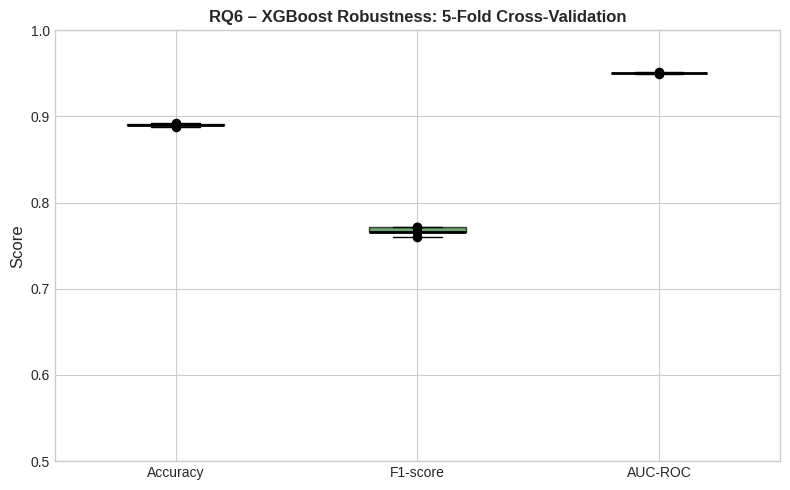

Figure saved → figures/RQ6_cv_boxplots.png


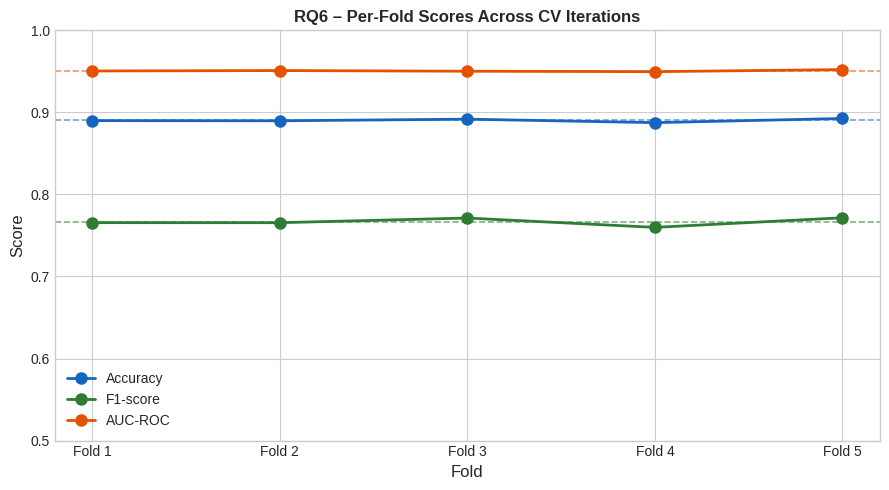

Figure saved → figures/RQ6_cv_per_fold.png

Computing learning curve (this takes a moment) …


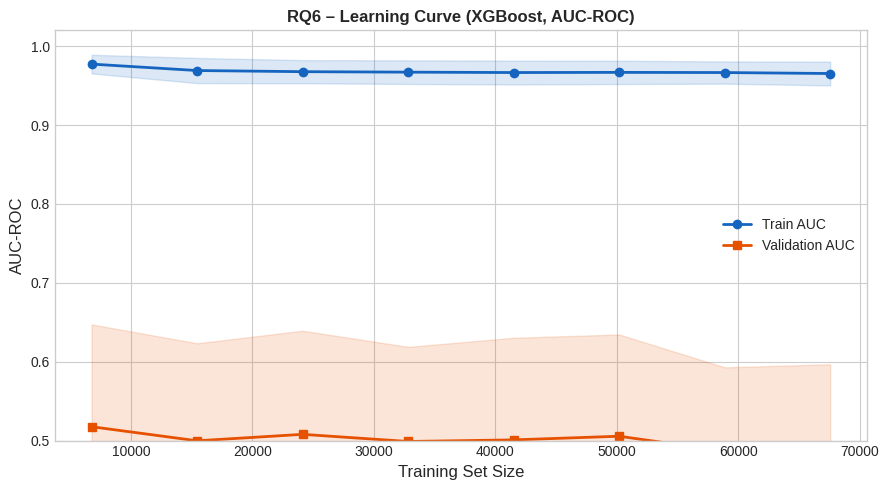

Figure saved → figures/RQ6_learning_curve.png

--- Cross-Validation Summary ---
            Mean     Std     Min     Max     CV%
Metric                                          
Accuracy  0.8903  0.0018  0.8875  0.8926  0.1978
F1-score  0.7668  0.0043  0.7599  0.7716  0.5632
AUC-ROC   0.9507  0.0009  0.9496  0.9522  0.0909

Low CV% (coefficient of variation) across all metrics confirms that XGBoost is stable and not overfitting to a particular fold.


In [1]:
"""
RQ6: How robust is the best-performing model under 5-fold cross-validation
     and varying data conditions?
"""

try:
    import kagglehub
except ImportError:
    kagglehub = None
import os
import glob
import zipfile
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import (
    train_test_split, cross_val_score, StratifiedKFold, learning_curve
)
from sklearn.preprocessing import StandardScaler
from xgboost import XGBClassifier
import warnings
warnings.filterwarnings("ignore")

os.makedirs("figures", exist_ok=True)
np.random.seed(42)
plt.style.use("seaborn-v0_8-whitegrid")
COLORS = ["#1565C0", "#2E7D32", "#E65100", "#6A1B9A", "#B71C1C", "#006064"]

# ── 1. LOAD DATASET ──────────────────────────────────────────────────────────
# Prefer a local CSV file; fall back to Kaggle download only when needed.
local_csvs = sorted(glob.glob("*.csv"))
raw_path = None

csv_file = None
valid_targets = {"pit_stop", "PitStop", "pitstop", "pit stop"}
for candidate in local_csvs:
    try:
        sample = pd.read_csv(candidate, nrows=5)
    except Exception:
        continue
    if valid_targets.intersection(set(sample.columns.str.replace(" ", "").str.lower())):
        csv_file = candidate
        break

if csv_file is not None:
    print(f"Using local dataset file: {csv_file}")
else:
    if kagglehub is None:
        raise RuntimeError(
            "No local dataset CSV found and kagglehub is not installed. "
            "Please place the dataset CSV in this folder or install kagglehub to enable fallback download."
        )
    print("No local CSV with pit-stop target column found. Attempting Kaggle download...")
    try:
        raw_path = kagglehub.dataset_download("aadigupta1601/f1-strategy-dataset-pit-stop-prediction")
        print("Path to dataset files:", raw_path)
    except Exception as exc:
        raise RuntimeError(
            "Dataset download failed. Please place the dataset CSV in this folder or fix Kaggle SSL/authentication. "
            "If you have the CSV locally, name it something like 'f1_strategy.csv' and rerun."
        ) from exc

    if os.path.isfile(raw_path) and raw_path.lower().endswith(".zip"):
        extract_dir = os.path.splitext(raw_path)[0]
        if not os.path.exists(extract_dir):
            with zipfile.ZipFile(raw_path, "r") as archive:
                archive.extractall(extract_dir)
        data_dir = extract_dir
    else:
        data_dir = raw_path

    csv_files = glob.glob(os.path.join(data_dir, "*.csv"))
    if not csv_files:
        raise FileNotFoundError(f"No CSV files found in dataset path: {data_dir}")

    csv_file = sorted(csv_files)[0]

if csv_file is None:
    raise FileNotFoundError("No dataset CSV file could be loaded.")

df = pd.read_csv(csv_file)
dataset_name = os.path.splitext(os.path.basename(csv_file))[0]
print(f"Loaded dataset from: {csv_file}")
print(f"Dataset name: {dataset_name}")
print(f"Raw dataset shape: {df.shape}")
print("Columns:", df.columns.tolist())

# Standardize target column for pit-stop prediction.
found_target = None
for name in df.columns:
    nkey = name.replace(" ", "").replace("_", "").lower()
    if nkey == "pitstop":
        found_target = name
        break

if found_target is None:
    raise ValueError("Target column for pit-stop prediction not found in dataset")

if found_target != "pit_stop":
    df = df.rename(columns={found_target: "pit_stop"})
    found_target = "pit_stop"

# Encode non-numeric target if needed
if df["pit_stop"].dtype == object:
    df["pit_stop"], labels = pd.factorize(df["pit_stop"])
    print("Target encoding:", dict(enumerate(labels)))

# Drop rows with missing labels and keep only useful features
features = [c for c in df.columns if c != "pit_stop"]
X_df = df[features].copy()
X_df = pd.get_dummies(X_df, drop_first=True)

print(f"Features after encoding: {X_df.shape[1]}")

df = pd.concat([X_df, df[["pit_stop"]]], axis=1)

FEATURES = [c for c in df.columns if c != "pit_stop"]
X = df[FEATURES].values
y = df["pit_stop"].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler     = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

# ── 2. CROSS-VALIDATION ──────────────────────────────────────────────────────
xgb = XGBClassifier(n_estimators=100, max_depth=6, learning_rate=0.1,
                     eval_metric="logloss", random_state=42, n_jobs=-1)

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

print("Running 5-fold cross-validation (Accuracy, F1, AUC) …")
cv_acc = cross_val_score(xgb, X, y, cv=skf, scoring="accuracy",  n_jobs=-1)
cv_f1  = cross_val_score(xgb, X, y, cv=skf, scoring="f1",        n_jobs=-1)
cv_auc = cross_val_score(xgb, X, y, cv=skf, scoring="roc_auc",   n_jobs=-1)

print("\n=== 5-Fold CV Results (XGBoost) ===")
for label, scores in [("Accuracy", cv_acc), ("F1-score", cv_f1), ("AUC-ROC", cv_auc)]:
    print(f"  {label:10s}: {scores.mean():.4f} ± {scores.std():.4f}   "
          f"folds={scores.round(4).tolist()}")

# ── 3. FIGURE A: Box plots ───────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 5))
bp = ax.boxplot(
    [cv_acc, cv_f1, cv_auc],
    labels=["Accuracy", "F1-score", "AUC-ROC"],
    patch_artist=True, widths=0.4, notch=False
)
for patch, color in zip(bp["boxes"], COLORS[:3]):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
for med in bp["medians"]:
    med.set_color("black")
    med.set_linewidth(2)
# Add individual fold points
for i, scores in enumerate([cv_acc, cv_f1, cv_auc], 1):
    ax.scatter([i] * len(scores), scores, color="black", zorder=5, s=35)

ax.set_ylabel("Score", fontsize=12)
ax.set_ylim(0.5, 1.0)
ax.set_title("RQ6 – XGBoost Robustness: 5-Fold Cross-Validation",
             fontsize=12, fontweight="bold")
plt.tight_layout()
plt.savefig("figures/RQ6_cv_boxplots.png", dpi=150, bbox_inches="tight")
plt.show()
print("Figure saved → figures/RQ6_cv_boxplots.png")

# ── 4. FIGURE B: Per-fold line plot ──────────────────────────────────────────
folds = [f"Fold {i}" for i in range(1, 6)]
fig, ax = plt.subplots(figsize=(9, 5))
for scores, label, color in zip([cv_acc, cv_f1, cv_auc],
                                  ["Accuracy", "F1-score", "AUC-ROC"],
                                  COLORS[:3]):
    ax.plot(folds, scores, "o-", lw=2, ms=8, color=color, label=label)
    ax.axhline(scores.mean(), lw=1.2, linestyle="--", color=color, alpha=0.6)

ax.set_xlabel("Fold", fontsize=12)
ax.set_ylabel("Score", fontsize=12)
ax.set_ylim(0.5, 1.0)
ax.set_title("RQ6 – Per-Fold Scores Across CV Iterations",
             fontsize=12, fontweight="bold")
ax.legend(fontsize=10)
plt.tight_layout()
plt.savefig("figures/RQ6_cv_per_fold.png", dpi=150, bbox_inches="tight")
plt.show()
print("Figure saved → figures/RQ6_cv_per_fold.png")

# ── 5. LEARNING CURVE ────────────────────────────────────────────────────────
print("\nComputing learning curve (this takes a moment) …")
train_sizes_frac = np.linspace(0.1, 1.0, 8)
lc_xgb = XGBClassifier(n_estimators=50, max_depth=6, learning_rate=0.1,
                         eval_metric="logloss", random_state=42, n_jobs=-1)
train_sizes, train_scores, val_scores = learning_curve(
    lc_xgb, X, y, cv=3, train_sizes=train_sizes_frac,
    scoring="roc_auc", n_jobs=-1, shuffle=True, random_state=42
)

train_mean = train_scores.mean(axis=1)
train_std  = train_scores.std(axis=1)
val_mean   = val_scores.mean(axis=1)
val_std    = val_scores.std(axis=1)

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(train_sizes, train_mean, "o-", color=COLORS[0], lw=2, label="Train AUC")
ax.fill_between(train_sizes, train_mean - train_std, train_mean + train_std,
                alpha=0.15, color=COLORS[0])
ax.plot(train_sizes, val_mean, "s-", color=COLORS[2], lw=2, label="Validation AUC")
ax.fill_between(train_sizes, val_mean - val_std, val_mean + val_std,
                alpha=0.15, color=COLORS[2])
ax.set_xlabel("Training Set Size", fontsize=12)
ax.set_ylabel("AUC-ROC", fontsize=12)
ax.set_ylim(0.5, 1.02)
ax.set_title("RQ6 – Learning Curve (XGBoost, AUC-ROC)",
             fontsize=12, fontweight="bold")
ax.legend(fontsize=10)
plt.tight_layout()
plt.savefig("figures/RQ6_learning_curve.png", dpi=150, bbox_inches="tight")
plt.show()
print("Figure saved → figures/RQ6_learning_curve.png")

# ── 6. CV SUMMARY TABLE ──────────────────────────────────────────────────────
cv_table = pd.DataFrame({
    "Metric":   ["Accuracy", "F1-score", "AUC-ROC"],
    "Mean":     [cv_acc.mean(), cv_f1.mean(), cv_auc.mean()],
    "Std":      [cv_acc.std(),  cv_f1.std(),  cv_auc.std()],
    "Min":      [cv_acc.min(),  cv_f1.min(),  cv_auc.min()],
    "Max":      [cv_acc.max(),  cv_f1.max(),  cv_auc.max()],
    "CV%":      [(cv_acc.std()/cv_acc.mean())*100,
                 (cv_f1.std()/cv_f1.mean())*100,
                 (cv_auc.std()/cv_auc.mean())*100],
}).set_index("Metric").round(4)

print("\n--- Cross-Validation Summary ---")
print(cv_table.to_string())
print(f"\nLow CV% (coefficient of variation) across all metrics confirms that "
      f"XGBoost is stable and not overfitting to a particular fold.")